In [23]:
import pybamm # loads pybamm package
import matplotlib.pyplot as plt # package for plotting
import numpy as np # for arrays
import pandas as pd # for structure use .csv for importing and exporting
import math # log, sin, exp
from scipy.integrate import solve_ivp # integration, used in accelerated simulation
import pickle # for saving simulations
from pybamm import exp, constants

import os, sys # path stuff
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from batfuns import *

%matplotlib widget

In [19]:
def nmc_volume_change_mohtat(sto,c_s_max):
    t_change = -1.10/100*(1-sto)
    return t_change

def graphite_volume_change_mohtat(sto,c_s_max):
    stoichpoints = np.array([0,0.12,0.18,0.24,0.50,1])
    thicknesspoints = np.array([0,2.406/100,3.3568/100,4.3668/100,5.583/100,13.0635/100])
    x = [sto]
    t_change = pybamm.Interpolant(stoichpoints, thicknesspoints, x, name=None, interpolator='linear', extrapolate=True, entries_string=None)
    return t_change
# cathode diffusion

def NMC_diffusivity_Siegel(sto, T):
    D_ref = 1.324294480583595e-15
    E_D_s = 18550
    arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    return D_ref * arrhenius

# anode diffusion
def graphite_diffusivity_Siegel(sto, T):
    D_ref = 6.288364258818414e-13
    E_D_s = 42770
    arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    return D_ref * arrhenius

# cathode kinetics
def NMC_electrolyte_exchange_current_density_Siegel(c_e, c_s_surf, c_s_max, T):
    m_ref = 6.244462163366815e-06
    E_r = 39570
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 / T))
    return (
        m_ref * arrhenius * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5
    )

# anode kinetics
def graphite_electrolyte_exchange_current_density_Siegel(c_e, c_s_surf, c_s_max, T):
    m_ref = 2.853316063573524e-07
    E_r = 37480
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 / T))
    return (m_ref * arrhenius * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5)

In [45]:
parameter_values = pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Siegel2022)
spme = pybamm.lithium_ion.SPMe({
                    "SEI": "constant",
                    "loss of active material": "stress-driven",
                    "lithium plating": "irreversible",
                    "stress-induced diffusion": "false",
                })



C_n_init = 4.1698
C_p_init = 5.5994

param = spme.param
eps_n_init = parameter_values.evaluate(C_n_init*3600/(param.n.L * param.n.prim.c_max * param.F* param.A_cc))
eps_p_init = parameter_values.evaluate(C_p_init*3600/(param.p.L * param.p.prim.c_max * param.F* param.A_cc))

parameter_values.update(
    {
        "Negative electrode active material volume fraction": eps_n_init,
        "Positive electrode active material volume fraction": eps_p_init,
        "Positive electrode diffusivity [m2.s-1]": NMC_diffusivity_Siegel,
        "Negative electrode diffusivity [m2.s-1]": graphite_diffusivity_Siegel,
        "Positive electrode exchange-current density [A.m-2]": NMC_electrolyte_exchange_current_density_Siegel,
        "Negative electrode exchange-current density [A.m-2]": graphite_electrolyte_exchange_current_density_Siegel,
        "Initial temperature [K]": 273.15+25,
        "Ambient temperature [K]": 273.15+25,
        "Lower voltage cut-off [V]": 2.5,
        "Upper voltage cut-off [V]": 4.29,
        "Positive electrode Poisson's ratio": 0.3,
        "Positive electrode Young's modulus [Pa]": 375e9,
        "Positive electrode reference concentration for free of deformation [mol.m-3]": 0,
        "Positive electrode partial molar volume [m3.mol-1]": 7.28e-7,
        "Positive electrode volume change": nmc_volume_change_mohtat,
        # Loss of active materials (LAM) model
        "Positive electrode LAM constant exponential term": 2,
        "Positive electrode critical stress [Pa]": 375e6,
        # mechanical properties
        "Negative electrode Poisson's ratio": 0.2,
        "Negative electrode Young's modulus [Pa]": 15e9,
        "Negative electrode reference concentration for free of deformation [mol.m-3]": 0,
        "Negative electrode partial molar volume [m3.mol-1]": 3.1e-6,   
        "Negative electrode volume change": graphite_volume_change_mohtat,
        # Loss of active materials (LAM) model
        "Negative electrode LAM constant exponential term": 2,
        "Negative electrode critical stress [Pa]": 60e6,
        # Other
        "Cell thermal expansion coefficient [m.K-1]": 1.48E-6,
        "Positive electrode LAM constant proportional term [s-1]": 4.0312e-08,
        "Negative electrode LAM constant proportional term [s-1]": 1.8157e-07,
        "Positive electrode LAM constant proportional term 2 [s-1]": -1.4406e-09,
        "Negative electrode LAM constant proportional term 2 [s-1]": -4.9170e-09,
        "Positive electrode LAM constant exponential term": 1.0776,
        "Negative electrode LAM constant exponential term": 1.0776,
        "SEI kinetic rate constant [m.s-1]":  4.608e-16,
        "EC diffusivity [m2.s-1]": 4.56607447e-19,#8.30909086e-19,
        "SEI growth activation energy [J.mol-1]": 1.874e+04,
        "Lithium plating kinetic rate constant [m.s-1]": 2.3586e-09,
        "Initial inner SEI thickness [m]": 0e-09,
        "Initial outer SEI thickness [m]": 5e-09,
        "SEI resistivity [Ohm.m]": 30000.0,
        "Li plating resistivity [Ohm.m]": 30000.0,
        "Li plating open-circuit potential [V]": 0.0,
        "Negative electrode LAM min stress [Pa]": -834604,
        "Negative electrode LAM max stress [Pa]": 834604,
        "Positive electrode LAM min stress [Pa]": -58973996,
        "Positive electrode LAM max stress [Pa]": 58973996,

    },
    check_already_exists=False,)


In [46]:
c_rate_d = "C/3"
c_rate_c = "C/3"

experiment = pybamm.Experiment(
    [
        ("Discharge at "+c_rate_d+" until 3V",
        "Rest for 10 sec",
        "Charge at "+c_rate_c+" until 4.2V", 
        "Hold at 4.2V until C/20")
    ]*40 ,
    # ] *40,
    termination="50% capacity",
#     cccv_handling="ode",
)

sim_0 = pybamm.Simulation(spme, experiment=experiment, parameter_values=parameter_values, 
                            solver=pybamm.CasadiSolver("safe"))
sol_0 = sim_0.solve(initial_soc=1)


In [47]:
t = sol_0["Time [s]"].entries
I = sol_0["Current [A]"].entries
Q = sol_0['Discharge capacity [A.h]'].entries
Vt = sol_0["Terminal voltage [V]"].entries

sigma_n = sol_0["Negative particle surface tangential stress [Pa]"].entries[0]
sigma_p = sol_0["Positive particle surface tangential stress [Pa]"].entries[0]

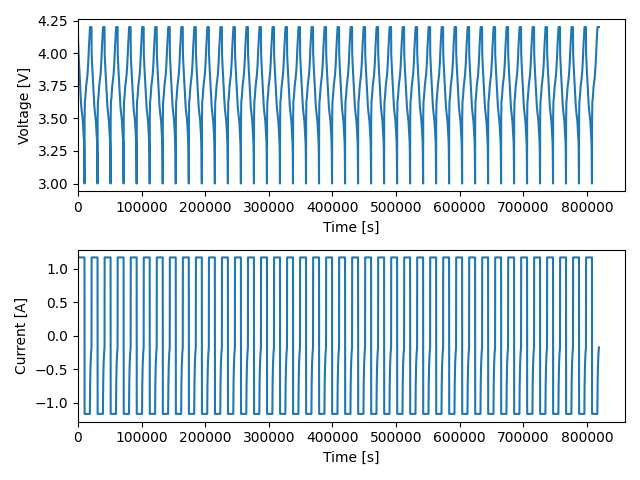

In [48]:
fig,ax = plt.subplots(2,1)
ax1 = ax.flat[0]
ax1.plot(t,Vt)
ax1.set_xlim(left=0)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Voltage [V]')
ax2 = ax.flat[1]
ax2.plot(t,I)
ax2.set_xlim(left=0)
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Current [A]')
fig.tight_layout()

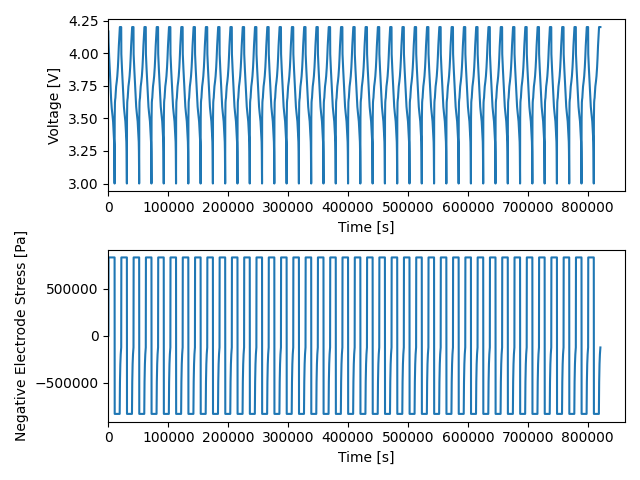

In [40]:
fig,ax = plt.subplots(2,1)
ax1 = ax.flat[0]
ax1.plot(t,Vt)
ax1.set_xlim(left=0)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Voltage [V]')
ax2 = ax.flat[1]
ax2.plot(t,sigma_n)
ax2.set_xlim(left=0)
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Negative Electrode Stress [Pa]')
fig.tight_layout()

In [26]:
dis_set = " until 2.7V"
experiment = pybamm.Experiment(
    [
        ("Discharge at "+c_rate_d + dis_set,
        "Rest for 10 sec",
        "Charge at "+c_rate_c+" until 4.2V", 
        "Hold at 4.2V until C/100")
    ] *30,
    termination="50% capacity",
#     cccv_handling="ode",
)

In [28]:
all_sumvars_dict = cycle_adaptive_simulation_V2(spme, parameter_values, experiment,SOC_0=1, save_at_cycles=-1)

RuntimeError: Error in Function::call for 'event_0' [MXFunction] at .../casadi/core/function.cpp:330:
.../casadi/core/function_internal.hpp:1644: Input 1 (i1) has mismatching shape. Got 263-by-1. Allowed dimensions, in general, are:
 - The input dimension N-by-M (here 143-by-1)
 - A scalar, i.e. 1-by-1
 - M-by-N if N=1 or M=1 (i.e. a transposed vector)
 - N-by-M1 if K*M1=M for some K (argument repeated horizontally)
 - N-by-P*M, indicating evaluation with multiple arguments (P must be a multiple of 1 for consistency with previous inputs)